# Latent Flow Matching Model for Frame Prediction

Latent flow matching experiment for Elastic Disks frame forecasting.

Flow Matching uses optimal transport paths to learn deterministic vector fields that transport noise to data, offering:
- Faster inference with fewer steps (typically 10-25 steps vs 50-1000 for diffusion)
- Simpler training objective (regression instead of denoising)
- Better computational efficiency while maintaining high quality

The model consists of:
1. A VAE encoder/decoder to compress images to/from latent space
2. A conditional flow matching model operating in latent space
3. A U-Net that predicts velocity fields in latent space conditioned on the current frame's latent

In [1]:
import os
import subprocess
import sys
from pathlib import Path

GITHUB_REPO_URL = "https://github.com/jordanshivers/generative-video-forecasting.git"
REPO_DIRNAME = "generative-video-forecasting"
INSTALL_REQUIREMENTS = True
RETRAIN = False

_current = Path.cwd().resolve()
REPO_ROOT = None
for _candidate in [_current, *_current.parents]:
    if (_candidate / "requirements.txt").exists() and (
        _candidate / "src" / "video_forecasting"
    ).is_dir():
        REPO_ROOT = _candidate
        break

if REPO_ROOT is None:
    _in_colab = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ
    if _in_colab:
        _target = Path("/content") / REPO_DIRNAME
        if not _target.exists():
            subprocess.check_call(["git", "clone", GITHUB_REPO_URL, str(_target)])
        for _candidate in [_target, *_target.parents]:
            if (_candidate / "requirements.txt").exists() and (
                _candidate / "src" / "video_forecasting"
            ).is_dir():
                REPO_ROOT = _candidate
                break
    if REPO_ROOT is None:
        raise FileNotFoundError(
            f"Could not find repo root from {_current}. Run locally from the repo root/notebooks "
            "or set GITHUB_REPO_URL for standalone Colab execution."
        )

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

if INSTALL_REQUIREMENTS:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-r",
            str(REPO_ROOT / "requirements.txt"),
        ]
    )

from video_forecasting.runtime import get_data_dir, get_output_dir

DATA_DIR = get_data_dir(REPO_ROOT)
OUTPUT_DIR = get_output_dir("train_elastic_disks_latent_flow_matching", REPO_ROOT)
print(f"Repo root: {REPO_ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Repo root: /content/generative-video-forecasting
Data dir: /content/generative-video-forecasting/data
Output dir: /content/generative-video-forecasting/outputs/train_elastic_disks_latent_flow_matching


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

from pathlib import Path
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
from tqdm import tqdm
import imageio
import math
import bisect
import warnings

warnings.filterwarnings("ignore")
from video_forecasting.runtime import get_device, set_seed
from video_forecasting.presets import batch_size_for_device, get_preset

set_seed(42)
device = get_device(prefer_mps=True)
print(f"PyTorch version: {torch.__version__}")
print(f"Selected device: {device}")

PyTorch version: 2.10.0+cu128
Selected device: cuda


In [3]:
from video_forecasting.datasets.elastic_disks import ElasticDisksDataset
from video_forecasting.models.vae import SpatialVAE as VAE
from video_forecasting.models.flow_matching import (
    FlowMatchingUtils,
    ConditionalLatentUNet,
    sample_latent_flow_matching,
)
from video_forecasting.training import (
    ContextFramePredictionDataset,
    FrameOnlyDataset,
    count_parameters,
    evaluate_flow_matching,
    evaluate_vae,
    train_flow_matching_epoch,
    train_vae_epoch,
)
from video_forecasting.visualization import (
    display_video,
    generate_flow_rollout_movie as generate_rollout_movie,
    save_reconstruction_frame,
    set_output_dir,
    visualize_flow_predictions as visualize_predictions,
    visualize_vae_reconstructions,
)

set_output_dir(OUTPUT_DIR)


PosixPath('/content/generative-video-forecasting/outputs/train_elastic_disks_latent_flow_matching')

## Load Elastic Disks Data

Load Elastic Disks datasets with train/test splits.

In [4]:
print("Loading Elastic Disks datasets...")
dataset_cfg = get_preset("elastic_disks")
num_sequences = dataset_cfg["num_sequences"]
max_sequences = dataset_cfg["max_sequences"]
sequence_length = dataset_cfg["sequence_length"]
frame_separation = dataset_cfg["frame_separation"]

train_dataset = ElasticDisksDataset(
    root=str(DATA_DIR),
    train=True,
    num_sequences=num_sequences,
    sequence_length=sequence_length,
    image_size=dataset_cfg["image_size"],
    num_particles=dataset_cfg["num_particles"],
    boundary="reflecting",
    render_mode=dataset_cfg["render_mode"],
    normalize=True,
    frame_separation=frame_separation,
    seed=42,
    max_sequences=max_sequences,
)

test_dataset = ElasticDisksDataset(
    root=str(DATA_DIR),
    train=False,
    num_sequences=num_sequences,
    sequence_length=sequence_length,
    image_size=dataset_cfg["image_size"],
    num_particles=dataset_cfg["num_particles"],
    boundary="reflecting",
    render_mode=dataset_cfg["render_mode"],
    normalize=True,
    frame_separation=frame_separation,
    seed=42,
    max_sequences=max_sequences,
)

print("Elastic Disks split:")
print(f"  Train: {len(train_dataset.sequences)} sequences")
print(f"  Test: {len(test_dataset.sequences)} sequences")
print(f"Train samples: {len(train_dataset)}; test samples: {len(test_dataset)}")


Loading Elastic Disks datasets...

Dataset initialized:
  Dataset: elastic_disks
  Split: train
  Total sequences: 2000
  Boundary: reflecting
  Render mode: hard
  Particles: 6
  Frame separation: 1
  Total pairs: 62000
  Image size: 64x64
  Channels: 1 (grayscale)

Dataset initialized:
  Dataset: elastic_disks
  Split: test
  Total sequences: 500
  Boundary: reflecting
  Render mode: hard
  Particles: 6
  Frame separation: 1
  Total pairs: 15500
  Image size: 64x64
  Channels: 1 (grayscale)
Elastic Disks split:
  Train: 2000 sequences
  Test: 500 sequences
Train samples: 62000; test samples: 15500


## Initialize VAE and Flow Matching Models

In [5]:
vae_cfg = get_preset("vae_spatial")
flow_cfg = get_preset("latent_flow_matching")
context_frames = flow_cfg["context_frames"]
# VAE parameters
latent_channels = 4
vae_hidden_dims = vae_cfg["hidden_dims"]
vae_beta = 5.0
vae_learning_rate = vae_cfg["learning_rate"]
vae_num_epochs = 200


print("VAE config:")
print(f"  latent_channels: {latent_channels}")
print(f"  hidden_dims: {vae_hidden_dims}")
print(f"  beta: {vae_beta}")
print(f"  learning_rate: {vae_learning_rate}")
print(f"  num_epochs: {vae_num_epochs}")


# Flow matching model parameters
base_channels = flow_cfg["base_channels"]
time_emb_dim = flow_cfg["time_emb_dim"]

vae = VAE(
    in_channels=1,
    latent_channels=latent_channels,
    hidden_dims=vae_hidden_dims,
).to(device)

flow_matching_model = ConditionalLatentUNet(
    latent_channels=latent_channels,
    condition_channels=context_frames * latent_channels,
    out_channels=latent_channels,
    time_emb_dim=time_emb_dim,
    base_channels=base_channels,
    channel_multipliers=(1, 2, 4),
    num_res_blocks=2,
).to(device)

print(f"VAE parameters: {count_parameters(vae):,}")
print(f"Flow matching model parameters: {count_parameters(flow_matching_model):,}")


VAE config:
  latent_channels: 4
  hidden_dims: [32, 64, 128]
  beta: 5.0
  learning_rate: 0.0003
  num_epochs: 200
VAE parameters: 452,841
Flow matching model parameters: 2,806,788


## Train VAE Models

First, train the VAE encoder/decoder to learn good latent representations. We'll train separate VAEs for Elastic Disks datasets.

In [6]:
# Create VAE training dataset (use all frames from both train and test)
# Compute unified target dimensions to ensure consistent sizing when concatenating datasets
max_height = max(train_dataset.target_height, test_dataset.target_height)
max_width = max(train_dataset.target_width, test_dataset.target_width)

vae_train_dataset = ConcatDataset(
    [
        FrameOnlyDataset(
            train_dataset, target_height=max_height, target_width=max_width
        ),
        FrameOnlyDataset(
            test_dataset, target_height=max_height, target_width=max_width
        ),  # Use test set too for VAE training
    ]
)

# Create data loaders
batch_size = batch_size_for_device(device, vae_cfg["batch_size"])
num_workers = 0

vae_train_loader = DataLoader(
    vae_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=device.type == "cuda",
)

print(f"VAE training datasets created:")
print(f"  Elastic Disks: {len(vae_train_dataset)} frames")

VAE training datasets created:
  Elastic Disks: 80000 frames


In [7]:
# optimizer_vae = torch.optim.Adam(vae.parameters(), lr=vae_learning_rate)
# scheduler_lr_vae = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer_vae, mode='min', factor=0.5, patience=5
# )
optimizer_vae = torch.optim.AdamW(
    vae.parameters(), lr=vae_learning_rate, weight_decay=1e-4
)
steps_per_epoch = len(vae_train_loader)
scheduler_lr_vae = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_vae,
    max_lr=vae_learning_rate,
    epochs=vae_num_epochs,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=10.0,
    final_div_factor=100.0,
)
vae_train_losses = []
vae_train_recon_losses = []
vae_train_kl_losses = []
load_vae = not RETRAIN
vae_path = OUTPUT_DIR / "vae_model.pt"
# Option to save reconstruction frames during training for MP4 creation
save_reconstruction_frames = True
reconstruction_frames_dir = OUTPUT_DIR / "vae_reconstruction_frames"
output_mp4_dir = OUTPUT_DIR / "output_mp4s"
if save_reconstruction_frames:
    reconstruction_frames_dir.mkdir(exist_ok=True)
    output_mp4_dir.mkdir(exist_ok=True)
    # Select sample images at the start (use fixed indices for consistency)
    num_sample_images = 1
    sample_indices = torch.randperm(len(vae_train_dataset))[:num_sample_images].tolist()
    print(
        f"Selected {num_sample_images} sample images for reconstruction tracking (indices: {sample_indices})"
    )
if load_vae and vae_path.exists():
    print(f"Loading VAE from {vae_path}...")
    vae.load_state_dict(torch.load(vae_path, map_location=device))
    vae.eval()
    print("Loaded VAE.")
else:
    if load_vae:
        print(f"VAE checkpoint not found at {vae_path}; training now.")
    else:
        print("Training Elastic Disks VAE.")
    for epoch in range(vae_num_epochs):
        recon_loss, kl_loss, loss = train_vae_epoch(
            vae, vae_train_loader, optimizer_vae, device, beta=vae_beta
        )
        vae_train_losses.append(loss)
        vae_train_recon_losses.append(recon_loss)
        vae_train_kl_losses.append(kl_loss)
        # scheduler_lr_vae.step(loss)
        scheduler_lr_vae.step()
        if (epoch) % 5 == 0:
            print(f"Epoch {epoch}/{vae_num_epochs}")
            print(f"  Total Loss: {loss:.6f}")
            print(f"  Recon Loss: {recon_loss:.6f}")
            print(f"  KL Loss: {kl_loss:.6f}")
            print()
            # Save reconstruction frame every 5 epochs
            if save_reconstruction_frames:
                save_reconstruction_frame(
                    vae,
                    vae_train_dataset,
                    sample_indices,
                    epoch,
                    reconstruction_frames_dir,
                    device,
                )
                print(f"  Saved reconstruction frame for epoch {epoch}")
    # Save VAE
    torch.save(vae.state_dict(), vae_path)
    print(f"VAE saved to {vae_path}")
    # Create MP4 from saved frames
    if save_reconstruction_frames:
        frame_files = sorted(reconstruction_frames_dir.glob("epoch_*.png"))
        if len(frame_files) > 0:
            print(f"\nCreating MP4 from {len(frame_files)} frames...")
            images = []
            for frame_file in frame_files:
                images.append(imageio.imread(frame_file))
            mp4_path = output_mp4_dir / "vae_training_reconstructions.mp4"
            fps = 2  # 2 frames per second (0.5 seconds per frame)
            imageio.mimwrite(str(mp4_path), images, fps=fps, codec="libx264", quality=8)
            print(f"✓ MP4 saved to {mp4_path}")
            display_video(mp4_path)
        else:
            print("No frames found to create MP4")
# Plot training curves
if len(vae_train_losses) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].plot(vae_train_losses, label="Total Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("VAE Total Loss")
    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(vae_train_recon_losses, label="Recon Loss", color="blue")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("VAE Reconstruction Loss")
    axes[1].legend()
    axes[1].grid(True)
    axes[2].plot(vae_train_kl_losses, label="KL Loss", color="orange")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].set_title("VAE KL Loss")
    axes[2].legend()
    axes[2].grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "vae_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

Selected 1 sample images for reconstruction tracking (indices: [67408])
Loading VAE from /content/generative-video-forecasting/outputs/train_elastic_disks_latent_flow_matching/vae_model.pt...
Loaded VAE.


## Train Flow Matching Models in Latent Space

Now train the flow matching models to predict future frame latents conditioned on current frame latents. The model learns to predict velocity fields that transport noise to target latents along optimal transport paths.

In [8]:
# Create data loaders for flow matching training
# These use the frame pairs from train_dataset and test_dataset
flow_matching_batch_size = batch_size_for_device(device, flow_cfg["batch_size"])
flow_matching_num_workers = 0

context_train_dataset = ContextFramePredictionDataset(train_dataset, context_frames=context_frames)
context_test_dataset = ContextFramePredictionDataset(test_dataset, context_frames=context_frames)

elastic_disks_train_loader = DataLoader(
    context_train_dataset,
    batch_size=flow_matching_batch_size,
    shuffle=True,
    num_workers=flow_matching_num_workers,
    pin_memory=device.type == "cuda",
)

elastic_disks_test_loader = DataLoader(
    context_test_dataset,
    batch_size=flow_matching_batch_size,
    shuffle=False,
    num_workers=flow_matching_num_workers,
    pin_memory=device.type == "cuda",
)

print(f"Flow matching data loaders created:")
print(f"  Train: {len(elastic_disks_train_loader)} batches")
print(f"  Test: {len(elastic_disks_test_loader)} batches")


Flow matching data loaders created:
  Train: 344 batches
  Test: 86 batches


In [9]:
# Train elastic_disks flow matching model
flow_matching_learning_rate = flow_cfg["learning_rate"]
flow_matching_num_epochs = flow_cfg["num_epochs"]
# Initialize Flow Matching Utils
flow_utils = FlowMatchingUtils(sigma_min=1e-5)
optimizer_fm_mnist = torch.optim.Adam(
    flow_matching_model.parameters(), lr=flow_matching_learning_rate
)
scheduler_lr_fm_mnist = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fm_mnist, mode="min", factor=0.5, patience=10
)
train_losses = []
val_losses = []
best_val_loss = float("inf")
load_fm_mnist = not RETRAIN
fm_path = OUTPUT_DIR / "latent_flow_matching_elastic_disks_model.pt"
# Make sure VAE is loaded
if not vae_path.exists():
    print("Missing VAE checkpoint; run the VAE training cell first.")
else:
    vae.load_state_dict(torch.load(vae_path, map_location=device))
    vae.eval()
    print("VAE loaded for flow matching training.")
if load_fm_mnist and fm_path.exists():
    print(f"Loading flow matching model from {fm_path}...")
    flow_matching_model.load_state_dict(torch.load(fm_path, map_location=device))
    flow_matching_model.eval()
    print("Loaded flow matching model.")
else:
    if load_fm_mnist:
        print(f"Flow matching checkpoint not found at {fm_path}; training now.")
    else:
        print("Training Elastic Disks latent flow matching model.")
    for epoch in range(flow_matching_num_epochs):
        # Train
        train_loss = train_flow_matching_epoch(
            flow_matching_model,
            vae,
            elastic_disks_train_loader,
            flow_utils,
            optimizer_fm_mnist,
            device,
        )
        # Evaluate on test set
        val_loss = evaluate_flow_matching(
            flow_matching_model, vae, elastic_disks_test_loader, flow_utils, device
        )
        # Store history
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        # Update learning rate scheduler
        scheduler_lr_fm_mnist.step(val_loss)
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(flow_matching_model.state_dict(), fm_path)
            print(
                f"Epoch {epoch + 1}/{flow_matching_num_epochs} - Saved best model (val_loss: {val_loss:.6f})"
            )
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch + 1}/{flow_matching_num_epochs}")
            print(f"  Train Loss: {train_loss:.6f}")
            print(f"  Val Loss: {val_loss:.6f}")
            print()
    print("Training completed!")
    print(f"Best validation loss: {best_val_loss:.6f}")
# Plot training curves
if len(train_losses) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.plot(train_losses, label="Train Loss", color="blue")
    ax.plot(val_losses, label="Val Loss", color="orange")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title("Elastic Disks Latent Flow Matching Model: Training Curves")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "latent_flow_matching_training_curves.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No training history available. Train the model first.")

VAE loaded for flow matching training.
Loading flow matching model from /content/generative-video-forecasting/outputs/train_elastic_disks_latent_flow_matching/latent_flow_matching_elastic_disks_model.pt...
Loaded flow matching model.
No training history available. Train the model first.


## Evaluation, Visualizations, and Rollouts

Load saved checkpoints, create prediction figures, and generate rollout movies.


Loading trained models...
Loaded VAE.
Loaded flow matching model.

Generating visualizations...


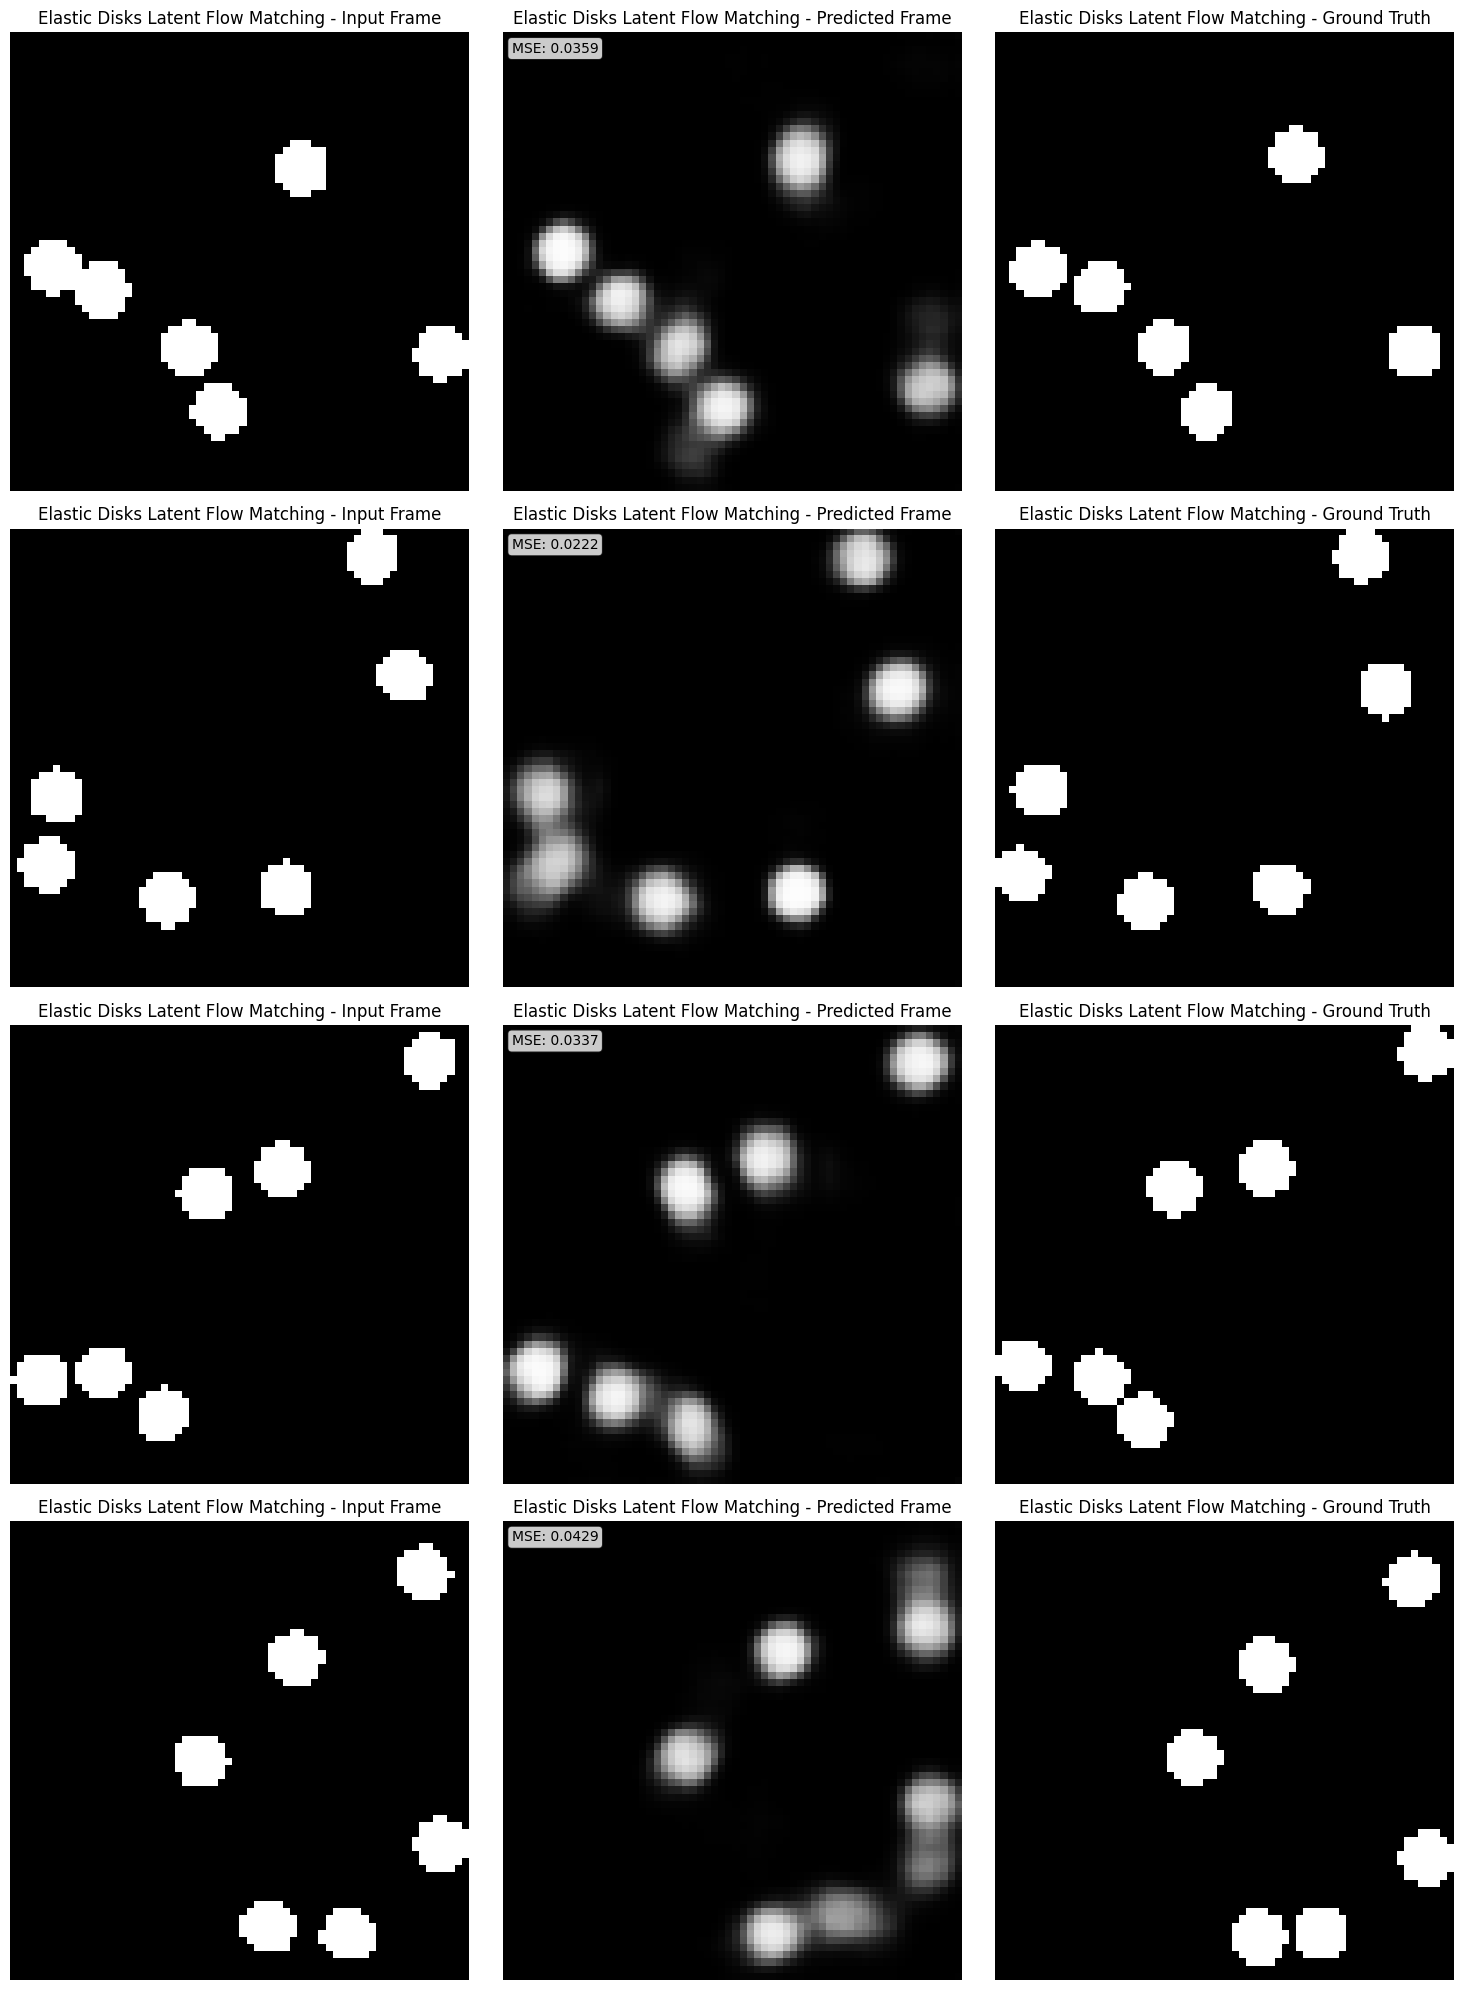

In [10]:
# Load trained models
vae_path = OUTPUT_DIR / "vae_model.pt"
fm_path = OUTPUT_DIR / "latent_flow_matching_elastic_disks_model.pt"
if vae_path.exists() and fm_path.exists():
    print(f"Loading trained models...")
    vae.load_state_dict(torch.load(vae_path, map_location=device))
    vae.eval()
    print("Loaded VAE.")
    flow_matching_model.load_state_dict(torch.load(fm_path, map_location=device))
    flow_matching_model.eval()
    print("Loaded flow matching model.")
    # Visualize predictions
    print("\nGenerating visualizations...")
    visualize_predictions(
        flow_matching_model,
        vae,
        context_test_dataset,
        flow_utils,
        num_samples=4,
        device=device,
        title_prefix="Elastic Disks Latent Flow Matching - ",
    )
else:
    print("Missing model files; run the training cells first.")
    if not vae_path.exists():
        print(f"  Missing: {vae_path}")
    if not fm_path.exists():
        print(f"  Missing: {fm_path}")


In [11]:
# Generate rollout movie
if vae_path.exists() and fm_path.exists():
    # Use first sequence from test dataset for rollout
    test_sequence_idx = 0
    test_sequence = test_dataset.sequences[test_sequence_idx]  # [T, C, H, W]
    print(
        f"Using test sequence {test_sequence_idx} with {len(test_sequence)} frames..."
    )
    print(f"Generating rollout movie for test sequence {test_sequence_idx}...")
    rollout_path = generate_rollout_movie(
        flow_matching_model=flow_matching_model,
        vae=vae,
        test_dataset=test_dataset,
        sequence=test_sequence,
        dataset_type="elastic_disks",
        frame_separation=frame_separation,
        context_frames=context_frames,
        start_frame=0,
        num_predictions=20,
        device=device,
        fps=10,
        output_dir=str(OUTPUT_DIR / "output_mp4s"),
        num_inference_steps=flow_cfg["num_inference_steps"],
        use_ddim=True,
    )
    print(f"Rollout movie saved to: {rollout_path}")
    display_video(rollout_path)
else:
    print("Missing model files; run the training cells first.")


Using test sequence 0 with 32 frames...
Generating rollout movie for test sequence 0...
Using sequence with shape (32, 1, 64, 64)...
  Sequence shape: 32 frames, 1 channels, 64x64
Generating 20 prediction steps...
  Starting from frame 0


Generating predictions: 100%|██████████| 20/20 [00:09<00:00,  2.17it/s]

Creating video frames...
Saving video to /content/generative-video-forecasting/outputs/train_elastic_disks_latent_flow_matching/output_mp4s/elastic_disks_sequence_0_latent_flow_matching_rollout.mp4...
Saved video to /content/generative-video-forecasting/outputs/train_elastic_disks_latent_flow_matching/output_mp4s/elastic_disks_sequence_0_latent_flow_matching_rollout.mp4
Rollout movie saved to: /content/generative-video-forecasting/outputs/train_elastic_disks_latent_flow_matching/output_mp4s/elastic_disks_sequence_0_latent_flow_matching_rollout.mp4
